# 02. NumPy로 5개 센서 데이터 만들기

**모듈**: M1 - Python 기초 + 개발환경 세팅
**날짜**: 2026-03-09

우리 프로젝트의 5개 센서 데이터를 NumPy로 시뮬레이션합니다.

```
📷 카메라    → 64x64x3 RGB 이미지
📏 거리센서  → 8방향 거리값
🎙 마이크    → 2채널 스테레오 소리
⚖️ IMU       → 속도/가속도/회전 6개 값
🧠 LLM       → 텍스트 ("앞에 장애물")
```

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# macOS 한글 폰트 설정
mpl.rcParams['font.family'] = 'AppleGothic'
mpl.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

# 재현 가능하도록 시드 고정
np.random.seed(42)
print('라이브러리 로드 완료! (한글 폰트: AppleGothic)')

라이브러리 로드 완료! (한글 폰트: AppleGothic)


## 1. 📷 카메라 센서 (시각)

로봇의 "눈". 64x64 픽셀 RGB 이미지로 앞을 봅니다.
- 각 픽셀: R, G, B 3개 값 (0~255)
- 전체: 64 × 64 × 3 = 12,288개 숫자

카메라 이미지 shape: (64, 64, 3)
데이터 타입: uint8
값 범위: 0 ~ 255
총 숫자 개수: 12,288


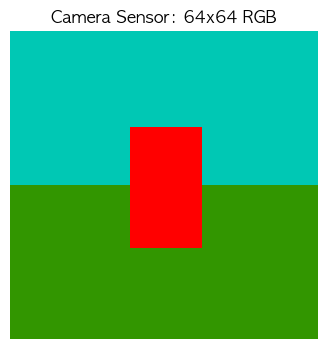

In [2]:
# 카메라 이미지 생성: 64x64 RGB
# 바닥(초록) + 하늘(파랑) + 장애물(빨강 사각형)

camera_image = np.zeros((64, 64, 3), dtype=np.uint8)

# 하늘 (위쪽 절반) - 파란색
camera_image[:32, :, 2] = 180  # Blue 채널
camera_image[:32, :, 1] = 200  # 약간의 Green

# 바닥 (아래쪽 절반) - 초록색
camera_image[32:, :, 1] = 150  # Green 채널
camera_image[32:, :, 0] = 50   # 약간의 Red

# 장애물 (빨간 사각형) - 중앙에
camera_image[20:45, 25:40, 0] = 255  # Red
camera_image[20:45, 25:40, 1] = 0
camera_image[20:45, 25:40, 2] = 0

print(f'카메라 이미지 shape: {camera_image.shape}')
print(f'데이터 타입: {camera_image.dtype}')
print(f'값 범위: {camera_image.min()} ~ {camera_image.max()}')
print(f'총 숫자 개수: {camera_image.size:,}')

plt.figure(figsize=(4, 4))
plt.imshow(camera_image)
plt.title('Camera Sensor: 64x64 RGB')
plt.axis('off')
plt.show()

## 2. 📏 거리 센서 (촉각 대체)

로봇 주변 8방향으로 레이저를 쏴서 장애물까지 거리를 측정.
- 8개 방향: N, NE, E, SE, S, SW, W, NW
- 값: 0.0 (바로 앞에 장애물) ~ 1.0 (최대 거리)

거리센서 shape: (8,)
각 방향별 거리:
   N: 0.2 ████ ⚠️
  NE: 0.5 ██████████ 
   E: 0.9 ██████████████████ 
  SE: 1.0 ████████████████████ 
   S: 1.0 ████████████████████ 
  SW: 1.0 ████████████████████ 
   W: 0.8 ████████████████ 
  NW: 0.4 ████████ 


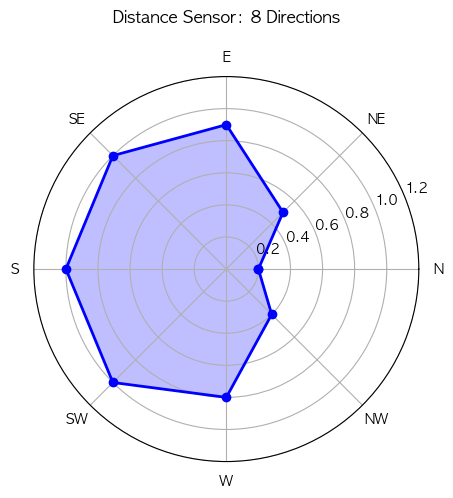

In [3]:
# 거리센서: 8방향 거리값
directions = ['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW']

# 시나리오: 앞(N)에 장애물이 가까이 있음
distance_data = np.array([0.2, 0.5, 0.9, 1.0, 1.0, 1.0, 0.8, 0.4])

print(f'거리센서 shape: {distance_data.shape}')
print(f'각 방향별 거리:')
for d, v in zip(directions, distance_data):
    bar = '█' * int(v * 20)
    danger = '⚠️' if v < 0.3 else ''
    print(f'  {d:>2}: {v:.1f} {bar} {danger}')

# 레이더 차트로 시각화
fig, ax = plt.subplots(1, 1, figsize=(5, 5), subplot_kw=dict(polar=True))
angles = np.linspace(0, 2 * np.pi, 8, endpoint=False).tolist()
angles += angles[:1]  # 닫기
values = distance_data.tolist() + [distance_data[0]]  # 닫기

ax.plot(angles, values, 'o-', linewidth=2, color='blue')
ax.fill(angles, values, alpha=0.25, color='blue')
ax.set_thetagrids([i * 45 for i in range(8)], directions)
ax.set_ylim(0, 1.2)
ax.set_title('Distance Sensor: 8 Directions', pad=20)
plt.show()

## 3. 🎙 오디오 센서 (청각)

스테레오 마이크로 소리의 방향과 세기를 감지.
- 2채널: 왼쪽(L), 오른쪽(R)
- 값: 소리 세기 (dB)

오디오 데이터 shape: (2, 100)
왼쪽 평균 세기: 0.072
오른쪽 평균 세기: 0.324
→ 소리가 오른쪽에서 옴!


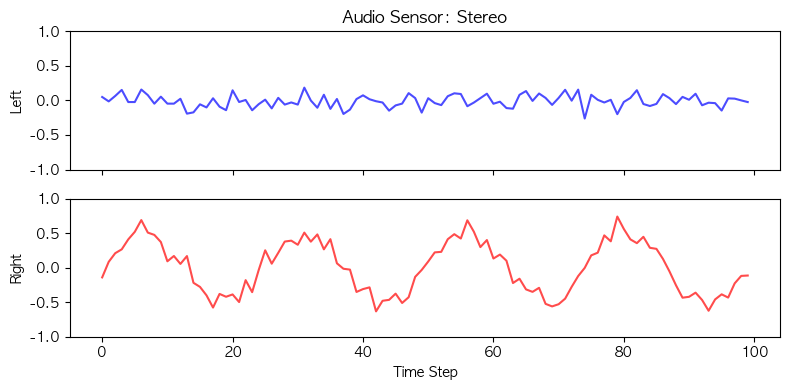

In [4]:
# 오디오: 2채널 스테레오, 100 샘플
# 시나리오: 오른쪽에서 소리가 남 (R > L)
time_steps = 100

# 기본 노이즈 + 오른쪽에서 오는 신호
audio_left = np.random.normal(0, 0.1, time_steps)  # 약한 소리
audio_right = np.random.normal(0, 0.1, time_steps) + 0.5 * np.sin(np.linspace(0, 8*np.pi, time_steps))  # 강한 소리

audio_data = np.stack([audio_left, audio_right])  # shape: (2, 100)

print(f'오디오 데이터 shape: {audio_data.shape}')
print(f'왼쪽 평균 세기: {np.abs(audio_left).mean():.3f}')
print(f'오른쪽 평균 세기: {np.abs(audio_right).mean():.3f}')
print(f'→ 소리가 오른쪽에서 옴!')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 4), sharex=True)
ax1.plot(audio_left, color='blue', alpha=0.7)
ax1.set_ylabel('Left')
ax1.set_ylim(-1, 1)
ax1.set_title('Audio Sensor: Stereo')

ax2.plot(audio_right, color='red', alpha=0.7)
ax2.set_ylabel('Right')
ax2.set_ylim(-1, 1)
ax2.set_xlabel('Time Step')

plt.tight_layout()
plt.show()

## 4. ⚖️ IMU 센서 (균형/운동)

로봇의 움직임 상태를 측정.
- 속도: vx, vy (2개)
- 가속도: ax, ay (2개)
- 회전: angular_velocity, angle (2개)
- 총 6개 값

IMU 데이터 shape: (6,)

IMU 상태:
  vx (전진): 0.50
  vy (횡방향): 0.10
  ax (전진가속): 0.00
  ay (횡가속): 0.05
  ω (회전속도): 0.20
  θ (방향°): 15.00


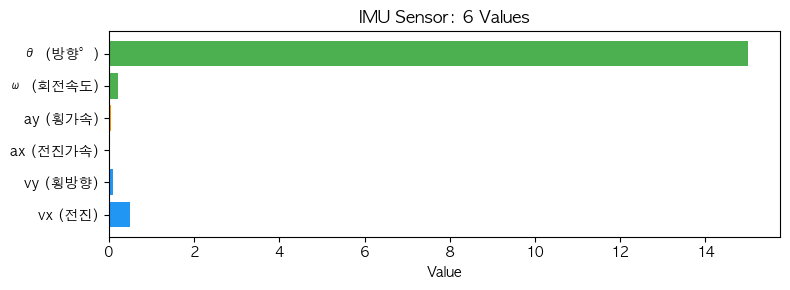

In [5]:
# IMU: 6개 값
# 시나리오: 앞으로 이동 중, 약간 오른쪽으로 회전
imu_data = np.array([
    0.5,   # vx: 전진 속도
    0.1,   # vy: 약간 오른쪽
    0.0,   # ax: 가속도 없음 (등속)
    0.05,  # ay: 약간의 횡가속도
    0.2,   # angular_velocity: 오른쪽 회전 중
    15.0   # angle: 현재 방향 (도)
])

imu_labels = ['vx (전진)', 'vy (횡방향)', 'ax (전진가속)', 'ay (횡가속)', 'ω (회전속도)', 'θ (방향°)']

print(f'IMU 데이터 shape: {imu_data.shape}')
print(f'\nIMU 상태:')
for label, val in zip(imu_labels, imu_data):
    print(f'  {label}: {val:.2f}')

fig, ax = plt.subplots(figsize=(8, 3))
colors = ['#2196F3', '#2196F3', '#FF9800', '#FF9800', '#4CAF50', '#4CAF50']
ax.barh(imu_labels, imu_data, color=colors)
ax.set_xlabel('Value')
ax.set_title('IMU Sensor: 6 Values')
plt.tight_layout()
plt.show()

## 5. 🧠 LLM 센서 (언어/의미)

LLM이 양방향으로 동작:
- **상황 해석**: 다른 센서 데이터를 보고 의미를 설명
- **명령 수신**: 사용자의 자연어 명령을 받음

여기서는 텍스트로 표현합니다. (나중에 Language Encoder가 벡터로 변환)

In [6]:
# LLM 센서: 텍스트 기반

# 상황 해석 (다른 센서 요약을 기반으로 LLM이 생성)
llm_interpretation = "앞 2m 거리에 빨간 장애물이 있습니다. 오른쪽에서 소리가 들립니다. 현재 전진 중입니다."

# 사용자 명령
llm_command = "오른쪽으로 돌아서 장애물을 피해"

print('=== LLM 센서 (양방향) ===')
print()
print(f'📥 상황 해석: "{llm_interpretation}"')
print(f'📤 사용자 명령: "{llm_command}"')
print()
print('→ 나중에 Language Encoder가 이 텍스트를 16차원 벡터로 변환합니다')
print(f'  예: interpretation → [0.8, -0.3, 0.5, ...] (16차원)')
print(f'  예: command → [0.1, 0.9, -0.2, ...] (16차원)')

=== LLM 센서 (양방향) ===

📥 상황 해석: "앞 2m 거리에 빨간 장애물이 있습니다. 오른쪽에서 소리가 들립니다. 현재 전진 중입니다."
📤 사용자 명령: "오른쪽으로 돌아서 장애물을 피해"

→ 나중에 Language Encoder가 이 텍스트를 16차원 벡터로 변환합니다
  예: interpretation → [0.8, -0.3, 0.5, ...] (16차원)
  예: command → [0.1, 0.9, -0.2, ...] (16차원)


## 6. 전체 센서 데이터 요약

5개 센서를 모두 하나의 딕셔너리로 묶어봅니다.

In [7]:
# 모든 센서 데이터를 하나로
sensor_data = {
    'camera': camera_image,           # (64, 64, 3)
    'distance': distance_data,        # (8,)
    'audio': audio_data,              # (2, 100)
    'imu': imu_data,                  # (6,)
    'llm': {
        'interpretation': llm_interpretation,
        'command': llm_command
    }
}

print('=== 5개 센서 데이터 요약 ===')
print()
for name, data in sensor_data.items():
    if name == 'llm':
        print(f'🧠 {name:>10}: 텍스트 (상황해석 + 명령)')
    else:
        emoji = {'camera': '📷', 'distance': '📏', 'audio': '🎙', 'imu': '⚖️'}[name]
        print(f'{emoji} {name:>10}: shape={data.shape}, dtype={data.dtype}')

print()
print('이 데이터가 Encoder → Fusion → World Model → Flow Matching 파이프라인을 통과합니다!')

=== 5개 센서 데이터 요약 ===

📷     camera: shape=(64, 64, 3), dtype=uint8
📏   distance: shape=(8,), dtype=float64
🎙      audio: shape=(2, 100), dtype=float64
⚖️        imu: shape=(6,), dtype=float64
🧠        llm: 텍스트 (상황해석 + 명령)

이 데이터가 Encoder → Fusion → World Model → Flow Matching 파이프라인을 통과합니다!


## 7. 센서 대시보드 시각화

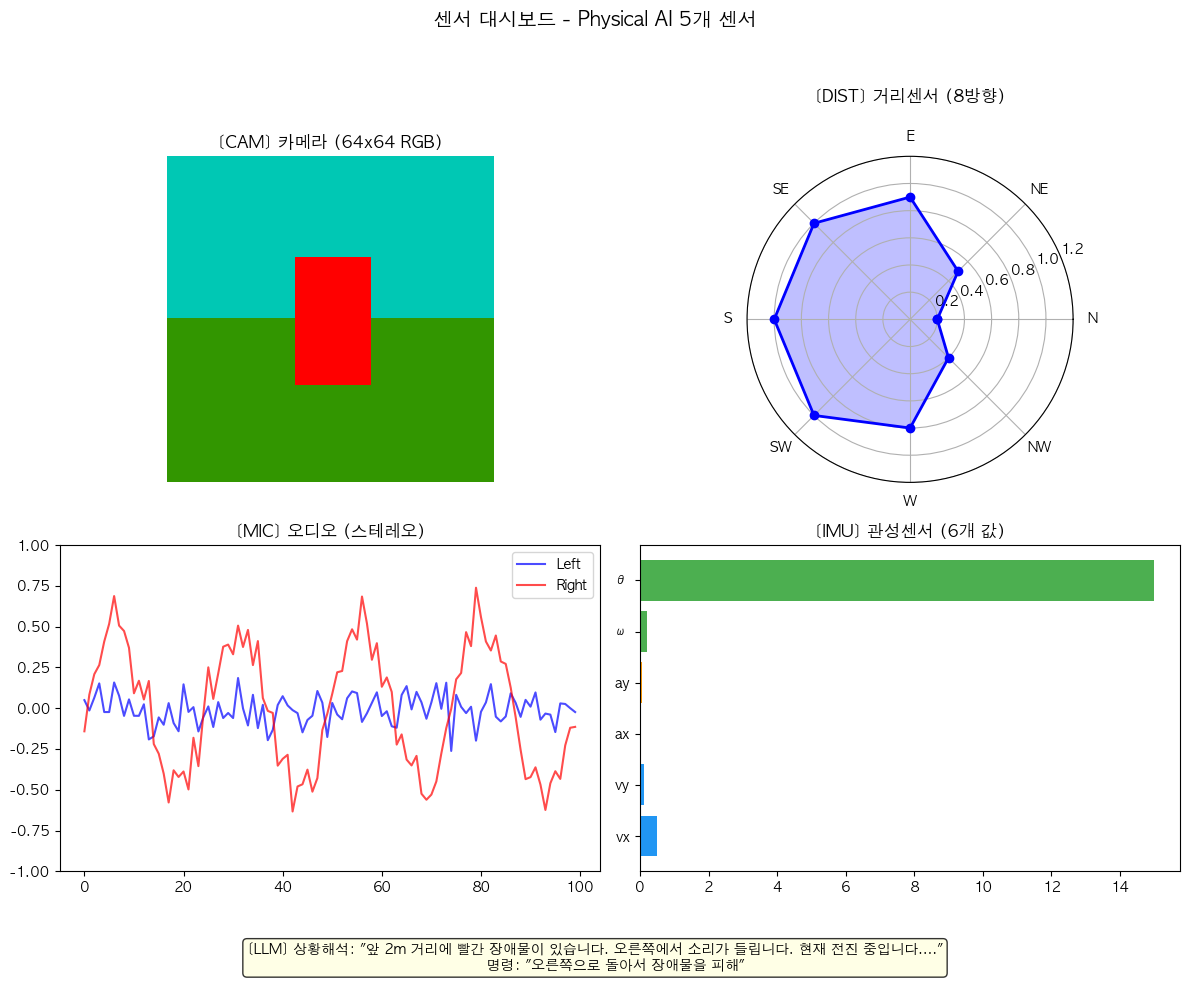


센서 대시보드 저장 완료: sensor_dashboard.png


In [8]:
# 4개 센서를 한 화면에 시각화 (LLM은 텍스트이므로 별도)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('센서 대시보드 - Physical AI 5개 센서', fontsize=14, fontweight='bold')

# 1. 카메라
axes[0, 0].imshow(camera_image)
axes[0, 0].set_title('[CAM] 카메라 (64x64 RGB)')
axes[0, 0].axis('off')

# 2. 거리센서 (레이더)
ax_radar = fig.add_subplot(2, 2, 2, polar=True)
angles_r = np.linspace(0, 2 * np.pi, 8, endpoint=False).tolist()
angles_r += angles_r[:1]
values_r = distance_data.tolist() + [distance_data[0]]
ax_radar.plot(angles_r, values_r, 'o-', linewidth=2, color='blue')
ax_radar.fill(angles_r, values_r, alpha=0.25, color='blue')
ax_radar.set_thetagrids([i * 45 for i in range(8)], directions)
ax_radar.set_ylim(0, 1.2)
ax_radar.set_title('[DIST] 거리센서 (8방향)', pad=20)
axes[0, 1].set_visible(False)  # 기존 축 숨기기

# 3. 오디오
axes[1, 0].plot(audio_left, color='blue', alpha=0.7, label='Left')
axes[1, 0].plot(audio_right, color='red', alpha=0.7, label='Right')
axes[1, 0].set_title('[MIC] 오디오 (스테레오)')
axes[1, 0].legend()
axes[1, 0].set_ylim(-1, 1)

# 4. IMU + LLM 텍스트
short_labels = ['vx', 'vy', 'ax', 'ay', 'ω', 'θ']
colors = ['#2196F3', '#2196F3', '#FF9800', '#FF9800', '#4CAF50', '#4CAF50']
axes[1, 1].barh(short_labels, imu_data, color=colors)
axes[1, 1].set_title('[IMU] 관성센서 (6개 값)')

# LLM 텍스트를 그림 아래에
fig.text(0.5, 0.02, f'[LLM] 상황해석: "{llm_interpretation[:50]}..."\n         명령: "{llm_command}"',
         ha='center', fontsize=10, style='italic',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout(rect=[0, 0.08, 1, 0.95])
plt.savefig('../examples/sensor_dashboard.png', dpi=100, bbox_inches='tight')
plt.show()

print('\n센서 대시보드 저장 완료: sensor_dashboard.png')